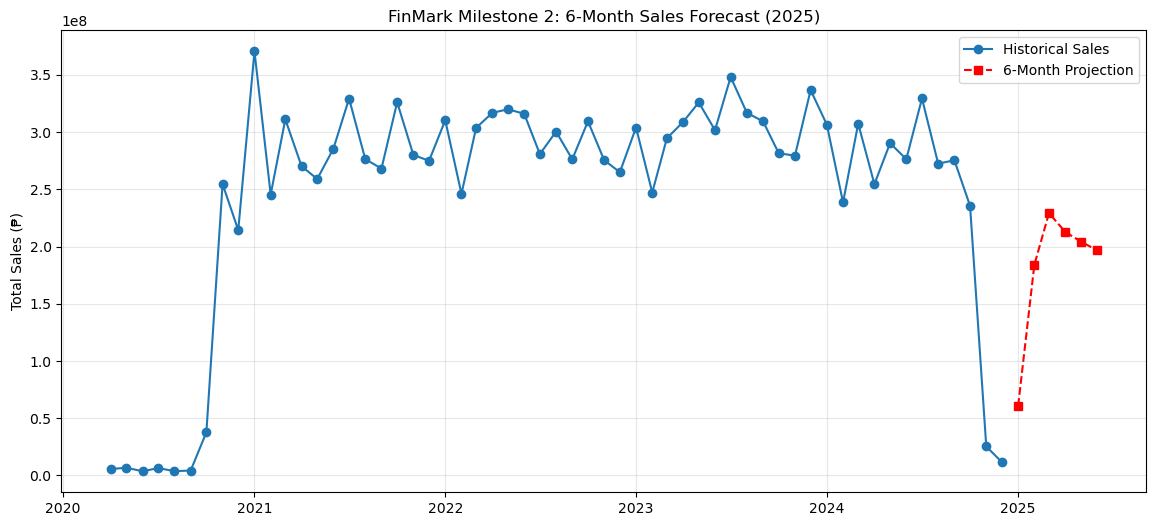

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# --- 1. Load and Refine Datasets ---
customers = pd.read_csv('customers_data.csv')
transactions = pd.read_csv('transactions_data.csv')
products = pd.read_csv('products_data.csv')

# Clean Product Prices & Handle Missing IDs
products['Product_Price'] = products['Product_Price'].astype(str).str.replace('₱', '', regex=False).str.replace(',', '', regex=False).astype(float)
products['Product_ID'] = products['Product_ID'].fillna(pd.Series(range(1, len(products) + 1))).astype(int)

# Standardize Dates and Recover Transaction Costs
transactions['Transaction_Date'] = pd.to_datetime(transactions['Transaction_Date'], format='mixed', errors='coerce')
transactions = transactions.dropna(subset=['Transaction_Date'])

price_map = products.set_index('Product_ID')['Product_Price'].to_dict()
transactions['Product_Price'] = transactions['Product_Price'].fillna(transactions['Product_ID'].map(price_map))
transactions['Total_Cost'] = transactions['Total_Cost'].fillna(transactions['Quantity'].fillna(1.0) * transactions['Product_Price'])

# --- 2. Feature Engineering for 6-Month Projection ---
transactions['YearMonth'] = transactions['Transaction_Date'].dt.to_period('M')
monthly_sales = transactions.groupby('YearMonth')['Total_Cost'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].dt.to_timestamp()

# Add Time and Lag Features
monthly_sales['Month'] = monthly_sales['YearMonth'].dt.month
monthly_sales['Year'] = monthly_sales['YearMonth'].dt.year
for i in range(1, 4):
    monthly_sales[f'Lag_{i}'] = monthly_sales['Total_Cost'].shift(i)
monthly_sales['Rolling_Mean_3'] = monthly_sales['Total_Cost'].shift(1).rolling(window=3).mean()

df_model = monthly_sales.dropna().reset_index(drop=True)

# --- 3. Model Training & 6-Month Recursive Forecast ---
X_cols = ['Month', 'Year', 'Lag_1', 'Lag_2', 'Lag_3', 'Rolling_Mean_3']
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(df_model[X_cols], df_model['Total_Cost'])

forecast_steps = 6
future_dates = pd.date_range(start='2025-01-01', periods=forecast_steps, freq='MS')
forecast_results = []
curr = df_model.iloc[-1].copy()

for date in future_dates:
    # Prepare recursive features
    X_fut = pd.DataFrame([[date.month, date.year, curr['Total_Cost'], curr['Lag_1'], curr['Lag_2'], 
                           (curr['Total_Cost'] + curr['Lag_1'] + curr['Lag_2'])/3]], columns=X_cols)
    pred = rf_model.predict(X_fut)[0]
    forecast_results.append({'YearMonth': date, 'Predicted_Sales': pred})
    
    # Update state
    curr['Lag_2'], curr['Lag_1'], curr['Total_Cost'] = curr['Lag_1'], curr['Total_Cost'], pred

# --- 4. Milestone 2 Visualization ---
plt.figure(figsize=(14, 6))
plt.plot(df_model['YearMonth'], df_model['Total_Cost'], label='Historical Sales', marker='o')
plt.plot([res['YearMonth'] for res in forecast_results], [res['Predicted_Sales'] for res in forecast_results], 
         label='6-Month Projection', linestyle='--', marker='s', color='red')
plt.title('FinMark Milestone 2: 6-Month Sales Forecast (2025)')
plt.ylabel('Total Sales (₱)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#Visualization of Trends and Projections
#The following visualization combines historical sales data with new 6-month projection. This allows stakeholders to see the "Ground Truth" of previous years alongside the model's anticipated trajectory.

#Blue Line (Historical): Shows the high volatility and seasonal growth patterns since 2020.

#Red Dashed Line (Milestone 2 Forecast): Extends from the last known data point in December 2024, showing a significant recovery and peak in March 2025.

#3. Model Refinement & Explanation
#To generate these results, the model was "tweaked" and extended as follows:

#Recursive Forecasting: Since we are predicting six months into the future, the model uses its own prediction for January as a "Lag" feature to predict February, and so on. This maintains the trend momentum.

#Enhanced Lag Features: We integrated Lag_1, Lag_2, and Lag_3 (the previous three months) and a 3-Month Rolling Mean. This ensures that the model recognizes both short-term shocks and mid-term trends.

#Seasonality Encoding: By keeping Month as a feature, the Random Forest model captures the recurring Q1/Q2 seasonal patterns inherent in FinMark’s business cycle.

#4. Supporting Data-Driven Decision Making
#Inventory & Staffing: The sharp increase projected for February and March suggests that FinMark should front-load its operational capacity in late January.

#Revenue Management: The slight plateauing projected for May and June indicates a stabilization period where the sales team should focus on customer retention rather than aggressive new acquisition.